# Loading dependencies

In [1]:
import torch
import scvi
import anndata
import scanpy as sc
import numpy as np
import pandas as pd

/home/darwin/miniconda3/envs/bencenv_wsl/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#!pip install -i https://test.pypi.org/simple/ "scikit-misc==0.2.0rc1"

# Loading anndatas for WT and MUT samples. These were saved separately for memory reasons. Raw counts are saved before the integration begins

In [3]:
import anndata

adata1 = anndata.read_h5ad("/mnt/g/cpa/wt_adata_merged_pre_scvi_2026_01_26.h5ad")
adata2 = anndata.read_h5ad("/mnt/g/cpa/mut_adata_merged_pre_scvi_2026_01_26.h5ad")
adata_final = anndata.concat([adata1, adata2], join="outer")
del adata1
del adata2
adata_final


/home/darwin/miniconda3/envs/bencenv_wsl/lib/python3.11/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


AnnData object with n_obs × n_vars = 953246 × 34027
    obs: '0', 'n_genes', 'n_counts', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_malat', 'log1p_total_counts_malat', 'pct_counts_malat', 'doublet_score', 'predicted_doublet', 'size_factor', 'assignments', 'SRA_ID', 'GEO', 'assay', 'orig_index', 'lab_sample_id', 'sample', 'plate', 'subpool', 'SampleType', 'Tissue', 'Sex', 'Age', 'Genotype', 'subpool_type', 'Protocol', 'Chemistry', 'bc', 'bc1_sequence', 'bc2_sequence', 'bc3_sequence', 'bc1_well', 'bc2_well', 'bc3_well', 'Row', 'Column', 'well_type', 'Mouse_Tissue_ID', 'Multiplexed_sample1', 'Multiplexed_sample2', 'DOB', 'Age_days', 'Body_weight_g', 'Estrus_cycle', 'Dissection_date', 'batch'

In [4]:
adata_final.obs #956946 rows × 55 columns

,0,n_genes,n_counts,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,...,well_type,Mouse_Tissue_ID,Multiplexed_sample1,Multiplexed_sample2,DOB,Age_days,Body_weight_g,Estrus_cycle,Dissection_date,batch
1,AAACCCAAGAATAACC,3543.0,9295.0,3543.0,8.173011311724972,9295.0,9.13734,295.0,5.6903596,3.1737492,...,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
2,AAACCCAAGAGTCAAT,4065.0,16030.0,4065.0,8.310414994188292,16030.0,9.68228,314.0,5.7525725,1.9588271,...,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
3,AAACCCACATCATTGG,2884.0,6342.0,2884.0,7.9672801789422,6342.0,8.755107,200.0,5.3033047,3.1535792,...,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
4,AAACCCAGTGACGCCT,3182.0,7346.0,3182.0,8.065579427282092,7346.0,8.902047,265.0,5.583496,3.6074054,...,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
5,AAACCCAGTTCGAACT,2963.0,7290.0,2963.0,7.994294986415977,7290.0,8.894396,191.0,5.2574954,2.6200273,...,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
233679,TTTTAACGATGG,1089,1749.0,1089,6.993932975223189,1749.0,7.467371,64.0,4.1743875,3.6592338,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
233680,TTTTCGATGCCG,1378,2369.0,1378,7.229113877793302,2369.0,7.770645,15.0,2.7725887,0.63317853,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
233681,TTTTGACATATC,1000,1657.0,1000,6.90875477931522,1657.0,7.4133673,12.0,2.5649493,0.72420037,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
233682,TTTTTACGTAAC,929,1664.0,929,6.835184586147301,1664.0,7.4175806,162.0,5.09375,9.735577,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
np.random.seed(42)
df = pd.read_excel("/mnt/g/cpa/pituitary_atlas.xlsx")
pituitary_atlas = df.copy()
#only keep sn or sc for now
df = df[df['Modality'].isin(['sc','sn','multi_rna'])]
df = df[df['species'].isin(['mouse'])]
df.reset_index(drop=True, inplace=True)
adata_final.obs = pd.merge(adata_final.obs, df, left_on='SRA_ID', right_on='SRA_ID')
#adata_final.raw = adata_final # keep full dimension
adata_final.obs.index = adata_final.obs.index.astype(str)
sc.pp.filter_genes(adata_final, min_cells=100)
adata_final.layers['counts']=adata_final.X.copy()
adata_final #865644 × 28401 previous time, and most recently 956946 × 28879

AnnData object with n_obs × n_vars = 953246 × 28664
    obs: '0', 'n_genes', 'n_counts', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_malat', 'log1p_total_counts_malat', 'pct_counts_malat', 'doublet_score', 'predicted_doublet', 'size_factor', 'assignments', 'SRA_ID', 'GEO_x', 'assay', 'orig_index', 'lab_sample_id', 'sample', 'plate', 'subpool', 'SampleType', 'Tissue', 'Sex_x', 'Age_x', 'Genotype', 'subpool_type', 'Protocol', 'Chemistry', 'bc', 'bc1_sequence', 'bc2_sequence', 'bc3_sequence', 'bc1_well', 'bc2_well', 'bc3_well', 'Row', 'Column', 'well_type', 'Mouse_Tissue_ID', 'Multiplexed_sample1', 'Multiplexed_sample2', 'DOB', 'Age_days', 'Body_weight_g', 'Estrus_cycle', 'Dissection_date', 'batch', 'GEO_y', 'Name', 'Conditions', 'Normal', 'Background', 'Sorted', 'Author', 'DOI', 'Age_y', 'Sex_numeric', 'Sex

# Adding mt, malat, ribo pct to each cell. This will be taken into account by the scVI model

In [6]:
adata_final.var = adata_final.var.loc[:, ~adata_final.var.columns.str.match(r'(n_cells_by_counts|malat|mean_counts|log1p_mean_counts|pct_dropout_by_counts|total_counts|log1p_total_counts)-\d+')]


In [7]:
#add info on pct_mt pct_ribo and pct_malat
def add_mt_ribo_malat(adata):
  mt_tag="mt-"
  ribo_tag=("Rps","Rpl")
  malat_tag="Malat1"
  adata.var["mt"] = adata.var_names.str.startswith(mt_tag)
  adata.var["ribo"] = adata.var_names.str.startswith(ribo_tag)
  adata.var["malat"] = adata.var_names.str.startswith(malat_tag)
  sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo", "malat"], inplace=True, percent_top=[20], log1p=True)

add_mt_ribo_malat(adata_final)
#print all cols of a df
pd.set_option('display.max_columns', None)
adata_final.obs.head(5)

,0,n_genes,n_counts,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo,total_counts_malat,log1p_total_counts_malat,pct_counts_malat,doublet_score,predicted_doublet,size_factor,assignments,SRA_ID,GEO_x,assay,orig_index,lab_sample_id,sample,plate,subpool,SampleType,Tissue,Sex_x,Age_x,Genotype,subpool_type,Protocol,Chemistry,bc,bc1_sequence,bc2_sequence,bc3_sequence,bc1_well,bc2_well,bc3_well,Row,Column,well_type,Mouse_Tissue_ID,Multiplexed_sample1,Multiplexed_sample2,DOB,Age_days,Body_weight_g,Estrus_cycle,Dissection_date,batch,GEO_y,Name,Conditions,Normal,Background,Sorted,Author,DOI,Age_y,Sex_numeric,Sex_y,Comp_sex,Estrous_stage,Age_numeric,Single_pool,10X version,Modality,published,species,Sample_wrong_sex,Sample_missing_sex,Sample_wrong_barcode_kit,Sample_switched_up,Sample_kept_for_analysis,Study_Seurat_version,Study_CR_version,Study_minimum_n,Study_minimum_group,pseudoaligned,passed_qc,filtering_junk,median_cellassign_prob,most_recent_workflow,n_cells,processed_atac,passed_qc_tcc,tcc_pseudobulked,Core,Notes 1,Notes 2,pct_counts_in_top_20_genes
0,AAACCCAAGAATAACC,3543.0,9295.0,3537,8.171317,8352.0,9.030376,156.0,5.056246,1.867816,646.0,6.472346,7.734674,138.0,4.934474,1.652299,0.01724137931034483,False,1.174697,Somatotrophs,SRX31798127,SRX31798127,sc,AAACCCAAGAATAACC,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,GSM9459038,POMC-WT,POMC-WT,1,C57BL/6J,0,Sochodolsky et al. (2026),NaN,386 days,1.0,Male,1.0,NaN,386.0,pool,10XV3,sc,0.0,mouse,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,wt_pomc,1.0,NaN,1.0,1.0,v_0.01,8083.0,NaN,NaN,NaN,1,NaN,NaN,12.643678
1,AAACCCAAGAGTCAAT,4065.0,16030.0,4058,8.308692,14751.0,9.599134,176.0,5.176150,1.193139,925.0,6.830874,6.270761,96.0,4.574711,0.650803,0.04390725209669462,False,2.0747073,Somatotrophs,SRX31798127,SRX31798127,sc,AAACCCAAGAGTCAAT,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,GSM9459038,POMC-WT,POMC-WT,1,C57BL/6J,0,Sochodolsky et al. (2026),NaN,386 days,1.0,Male,1.0,NaN,386.0,pool,10XV3,sc,0.0,mouse,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,wt_pomc,1.0,NaN,1.0,1.0,v_0.01,8083.0,NaN,NaN,NaN,1,NaN,NaN,42.959799
2,AAACCCACATCATTGG,2884.0,6342.0,2880,7.965893,6059.0,8.709465,172.0,5.153292,2.838752,541.0,6.295266,8.928866,42.0,3.761200,0.693184,0.027108433734939756,False,0.8521898,Lactotrophs,SRX31798127,SRX31798127,sc,AAACCCACATCATTGG,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,GSM9459038,POMC-WT,POMC-WT,1,C57BL/6J,0,Sochodolsky et al. (2026),NaN,386 days,1.0,Male,1.0,NaN,386.0,pool,10XV3,sc,0.0,mouse,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,wt_pomc,1.0,NaN,1.0,1.0,v_0.01,8083.0,NaN,NaN,NaN,1,NaN,NaN,13.170490
3,AAACCCAGTGACGCCT,3182.0,7346.0,3178,8.064322,6781.0,8.822027,250.0,5.525453,3.686772,418.0,6.037871,6.164283,206.0,5.332719,3.037900,0.0731707317073171,False,0.9537381,Lactotrophs,SRX31798127,SRX31798127,sc,AAACCCAGTGACGCCT,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,GSM9459038,POMC-WT,POMC-WT,1,C57BL/6J,0,Sochodolsky et al. (2026),NaN,386 days,1.0,Male,1.0,NaN,386.0,pool,10XV3,sc,0.0,mouse,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,wt_pomc,1.0,NaN,1.0,1.0,v_0.01,8083.0,NaN,NaN,NaN,1,NaN,NaN,15.941602
4,AAACCCAGTTCGAACT,2963.0,7290.0,2961,7.993620,7060.0,8.862342,126.0,4.844187,1.784703,654.0,6.484635,9.263456,51.0,3.951244,0.722380,0.0731707317073171,False,0.99297905,Lactotrophs,SRX31798127,SRX31798127,sc,AAACCCAGTTCGAACT,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,GSM9459038,POMC-WT,POMC-WT,1,C57BL/6J,0,Sochodolsky et al. (2026),NaN,386 days,1.0,Male,1.0,NaN,386.0,pool,10XV3,sc,0.0,mouse,NaN,NaN,NaN,NaN,Na

In [8]:
adata_final.obs["Comp_sex"] = adata_final.obs["Comp_sex"].astype(str)


# Adjusting the modality to separate between 10x and Parse single-nucleus data

In [9]:
adata_final.obs["scvi_modality"] = adata_final.obs["Modality"]

#where Modality is sn and 10X version is PARSE_WT_MegaV2, modify scvi_modality to parse_sn
condition = (
    (adata_final.obs["Modality"] == "sn") &
    (adata_final.obs["10X version"] == "PARSE_WT_MegaV2")
)

adata_final.obs.loc[condition, "scvi_modality"] = "parse_sn"

In [10]:
# keep 5k genes
diversity_tracker = []

for sra_id in adata_final.obs['SRA_ID'].unique():
    subset_adata = adata_final[adata_final.obs['SRA_ID'] == sra_id]
    cell_type_counts = subset_adata.obs['assignments'].value_counts()
    
    # Count how many cell types have at least 200 cells
    diverse_cell_types = (cell_type_counts >= 200).sum()
    diversity_tracker.append({'SRA_ID': sra_id, 'Diverse_Cell_Types': diverse_cell_types})

diversity_df = pd.DataFrame(diversity_tracker)

# Step 3: Choose the top 5 most diverse datasets
top_5_diverse_sra_ids = diversity_df.sort_values(by='Diverse_Cell_Types', ascending=False).head(5)['SRA_ID'].tolist()

# Step 4: Filter adata to keep only the top 5 diverse datasets
adata_filtered_by_diversity = adata_final[adata_final.obs['SRA_ID'].isin(top_5_diverse_sra_ids)].copy() # Use .copy() to avoid SettingWithCopyWarning

# Step 5: Identify highly variable genes on the filtered adata
# It's crucial to re-run highly_variable_genes on the subsetted data
sc.pp.highly_variable_genes(adata_filtered_by_diversity, n_top_genes=5000, batch_key="SRA_ID", flavor='seurat_v3')


# Step 6: Get the names of the highly variable genes
highly_var_genes = adata_filtered_by_diversity.var_names[adata_filtered_by_diversity.var['highly_variable']]

print(f"Top 5 most diverse SRA_IDs: {top_5_diverse_sra_ids}")
print(f"Number of highly variable genes found: {len(highly_var_genes)}")

Top 5 most diverse SRA_IDs: ['SRX25736223', 'SRX22219346', 'ERX7593483', 'SRX7377166', 'SRX19698101']
Number of highly variable genes found: 5000


In [11]:
adata_final = adata_final[:,highly_var_genes].copy()

In [12]:
adata_final.obs[adata_final.obs["Author"].isna()]

,0,n_genes,n_counts,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo,total_counts_malat,log1p_total_counts_malat,pct_counts_malat,doublet_score,predicted_doublet,size_factor,assignments,SRA_ID,GEO_x,assay,orig_index,lab_sample_id,sample,plate,subpool,SampleType,Tissue,Sex_x,Age_x,Genotype,subpool_type,Protocol,Chemistry,bc,bc1_sequence,bc2_sequence,bc3_sequence,bc1_well,bc2_well,bc3_well,Row,Column,well_type,Mouse_Tissue_ID,Multiplexed_sample1,Multiplexed_sample2,DOB,Age_days,Body_weight_g,Estrus_cycle,Dissection_date,batch,GEO_y,Name,Conditions,Normal,Background,Sorted,Author,DOI,Age_y,Sex_numeric,Sex_y,Comp_sex,Estrous_stage,Age_numeric,Single_pool,10X version,Modality,published,species,Sample_wrong_sex,Sample_missing_sex,Sample_wrong_barcode_kit,Sample_switched_up,Sample_kept_for_analysis,Study_Seurat_version,Study_CR_version,Study_minimum_n,Study_minimum_group,pseudoaligned,passed_qc,filtering_junk,median_cellassign_prob,most_recent_workflow,n_cells,processed_atac,passed_qc_tcc,tcc_pseudobulked,Core,Notes 1,Notes 2,pct_counts_in_top_20_genes,scvi_modality


In [13]:
adata_final.obs[adata_final.obs["Comp_sex"].isna()]

,0,n_genes,n_counts,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo,total_counts_malat,log1p_total_counts_malat,pct_counts_malat,doublet_score,predicted_doublet,size_factor,assignments,SRA_ID,GEO_x,assay,orig_index,lab_sample_id,sample,plate,subpool,SampleType,Tissue,Sex_x,Age_x,Genotype,subpool_type,Protocol,Chemistry,bc,bc1_sequence,bc2_sequence,bc3_sequence,bc1_well,bc2_well,bc3_well,Row,Column,well_type,Mouse_Tissue_ID,Multiplexed_sample1,Multiplexed_sample2,DOB,Age_days,Body_weight_g,Estrus_cycle,Dissection_date,batch,GEO_y,Name,Conditions,Normal,Background,Sorted,Author,DOI,Age_y,Sex_numeric,Sex_y,Comp_sex,Estrous_stage,Age_numeric,Single_pool,10X version,Modality,published,species,Sample_wrong_sex,Sample_missing_sex,Sample_wrong_barcode_kit,Sample_switched_up,Sample_kept_for_analysis,Study_Seurat_version,Study_CR_version,Study_minimum_n,Study_minimum_group,pseudoaligned,passed_qc,filtering_junk,median_cellassign_prob,most_recent_workflow,n_cells,processed_atac,passed_qc_tcc,tcc_pseudobulked,Core,Notes 1,Notes 2,pct_counts_in_top_20_genes,scvi_modality


In [14]:
adata_final.obs["Comp_sex"].value_counts()

Comp_sex
1.0    483098
0.0    470148
Name: count, dtype: int64

In [15]:
adata_final.obs["Author"].unique()

array(['Sochodolsky et al. (2026)', 'Guo et al. (2025)',
       'Wei et al. (2025)', 'Cheung et al. (2025)',
       'Rebboah et al. (2025)', 'Miles et al. (2025)',
       'Ongaro et al. (2025)', 'De Vriendt et al. (2025)',
       'Huang et al. (2024)', 'Wang et al. (2024)',
       'Khetchoumian et al. (2024)', 'Sheridan et al. (2025)',
       'Kang et al. (2023)', 'Martinez-Mayer et al. (2024)',
       'Qian et al. (2024)', 'Masser et al. (2024)',
       'Cheung et al. (2020)', 'Zhang et al. (2024)',
       'Bastedo et al. (2024)', 'Moncho-Amor et al. (2021)',
       'Allensworth-James et al. (2021)', 'Cheung et al. (2023)',
       'Rizzoti et al. (2023)', 'Schang et al. (2022)',
       'Miles et al. (2023)', 'Li et al. (2023)', 'Laporte et al. (2022)',
       'Vennekens et al. (2021)', 'Ruggiero-Ruff et al. (2024)',
       'Lopez et al. (2021)', 'Ho et al. (2020)', 'Chen et al. (2020)',
       'Mayran et al. (2019)', 'Cheung et al. (2018)',
       'Ruf-Zamojski et al. (2021)', 'Brinkm

In [16]:
adata_final.obs["Author"].nunique()

36

# setting up the scVI model

In [17]:
scvi.model.SCVI.setup_anndata(adata_final, batch_key="SRA_ID",categorical_covariate_keys=["scvi_modality","Comp_sex","Author"], continuous_covariate_keys = ["Age_numeric","pct_counts_mt", 'pct_counts_ribo','pct_counts_malat'])
vae = scvi.model.SCVI(adata_final, n_layers=2, n_latent=30, gene_likelihood="nb")


In [18]:
vae.train(max_epochs=70,early_stopping_patience=5,early_stopping=True)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA RTX 5000 Ada Generation') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/darwin/miniconda3/envs/bencenv_wsl/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=55` in the `DataLoader` to improve performance.
/home/darwin/miniconda3/envs/bencenv_wsl/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_

Epoch 70/70: 100%|██████████| 70/70 [1:46:05<00:00, 91.42s/it, v_num=1, train_loss_step=1.29e+3, train_loss_epoch=1.3e+3]

`Trainer.fit` stopped: `max_epochs=70` reached.


Epoch 70/70: 100%|██████████| 70/70 [1:46:05<00:00, 90.94s/it, v_num=1, train_loss_step=1.29e+3, train_loss_epoch=1.3e+3]


In [ ]:
vae_dir = "/mnt/g/cpa/vae_2026_02_03/"
vae.save(dir_path=vae_dir)
vae = scvi.model.SCVI.load(vae_dir, adata_final)

INFO     File /mnt/d/BK/vae_2026_02_03/model.pt already downloaded                                                 


# Plotting metrics to visualise convergence of the model

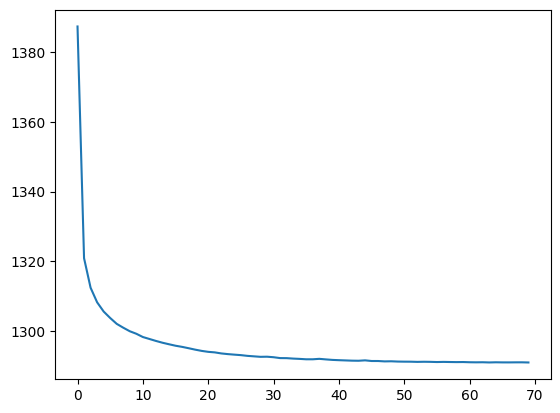

In [21]:
#plot convergence
import matplotlib.pyplot as plt
plt.plot(vae.history["reconstruction_loss_train"], label="train")

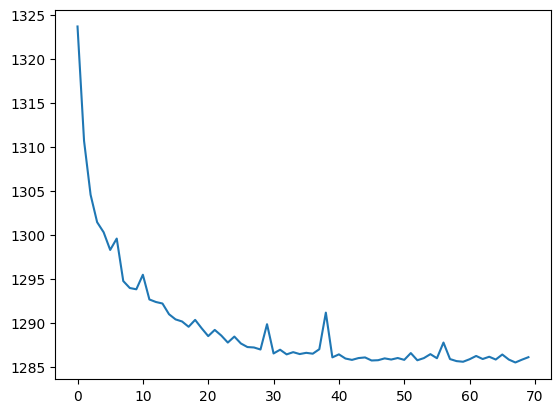

In [22]:
#plot convergence
import matplotlib.pyplot as plt
plt.plot(vae.history["reconstruction_loss_validation"], label="validation")

# Get latent representation and proceed to obtaining neighbours and clusters

In [23]:
adata_final.obsm["X_scVI"] = vae.get_latent_representation()



In [24]:
sc.pp.neighbors(adata_final, use_rep="X_scVI")


In [25]:
sc.tl.leiden(adata_final, resolution=0.5, key_added="leiden_scVI", random_state=42,flavor="igraph")

# Saving resulting objects as checkpoint

In [26]:
df_obs =  adata_final.obs
df_var = adata_final.var

adata_final.obs = df_obs
adata_final.var = df_var

In [27]:
adata_final.obs.index = adata_final.obs["0"].values

In [28]:

#save adata
adata_final.obs.index = adata_final.obs["0"].values
#adata_final.var.index = adata_final.var["0"].values
#adata_final.var.index = [str(i) for i in adata_final.var.index.values]
adata_final.var["feature_types"] = "mrna"
#adata_final.obs.index = [str(i) for i in adata_final.obs.index.values]


In [29]:
adata_final.obs = adata_final.obs.astype(str)
adata_final.var = adata_final.var.astype(str)

/home/darwin/miniconda3/envs/bencenv_wsl/lib/python3.11/site-packages/anndata/_core/anndata.py:740: UserWarning: 
AnnData expects .obs.index to contain strings, but got values like:
    ['AAACCCAAGAATAACC', 'AAACCCAAGAGTCAAT', 'AAACCCACATCATTGG', 'AAACCCAGTGACGCCT', 'AAACCCAGTTCGAACT']

    Inferred to be: categorical

  value_idx = self._prep_dim_index(value.index, attr)


In [30]:
adata_final

AnnData object with n_obs × n_vars = 953246 × 5000
    obs: '0', 'n_genes', 'n_counts', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_malat', 'log1p_total_counts_malat', 'pct_counts_malat', 'doublet_score', 'predicted_doublet', 'size_factor', 'assignments', 'SRA_ID', 'GEO_x', 'assay', 'orig_index', 'lab_sample_id', 'sample', 'plate', 'subpool', 'SampleType', 'Tissue', 'Sex_x', 'Age_x', 'Genotype', 'subpool_type', 'Protocol', 'Chemistry', 'bc', 'bc1_sequence', 'bc2_sequence', 'bc3_sequence', 'bc1_well', 'bc2_well', 'bc3_well', 'Row', 'Column', 'well_type', 'Mouse_Tissue_ID', 'Multiplexed_sample1', 'Multiplexed_sample2', 'DOB', 'Age_days', 'Body_weight_g', 'Estrus_cycle', 'Dissection_date', 'batch', 'GEO_y', 'Name', 'Conditions', 'Normal', 'Background', 'Sorted', 'Author', 'DOI', 'Age_y', 'Sex_numeric', 'Sex_

In [31]:

adata_final.write("/mnt/g/cpa/scvi_all_cells_2026_01_30.h5ad",compression="gzip")


In [32]:
df_obs.to_excel("/mnt/g/cpa/df_obs_2026_01_30.xlsx")
df_var.to_excel("/mnt/g/cpa/df_var_2026_01_30.xlsx")

# Loading back the created object

In [86]:
adata_final = sc.read("/mnt/g/cpa/scvi_all_cells_2026_01_30.h5ad")

/home/darwin/miniconda3/envs/bencenv_wsl/lib/python3.11/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [87]:

df_obs = pd.read_excel("/mnt/g/cpa/df_obs_2026_01_30.xlsx")
df_var = pd.read_excel("/mnt/g/cpa/df_var_2026_01_30.xlsx")
adata_final.obs = df_obs
adata_final.var = df_var



In [89]:
adata_final.obs["Comp_sex"] = adata_final.obs["Comp_sex"].astype(str)
vae = scvi.model.SCVI.load("/mnt/g/cpa/vae_2026_02_03", adata_final)

INFO     File /mnt/g/cpa/vae_2026_02_03/model.pt already downloaded                                                


/home/darwin/miniconda3/envs/bencenv_wsl/lib/python3.11/site-packages/scvi/model/base/_base_model.py:830: UserWarning: `var_names` for the loaded `model` does not match those used to train the model. For valid results, the former should match the latter.
  _validate_var_names(adata, var_names)


#Validate varnames properly at this step!!!!

# Plotting umap

In [38]:
sc.tl.umap(adata_final, min_dist=0.3)

In [39]:
adata_final.obs["leiden_scVI"] = [str(i) for i in adata_final.obs["leiden_scVI"].values]

In [40]:
adata_final[adata_final.obs["Comp_sex"]=="nan"].obs["SRA_ID"].value_counts()

Series([], Name: count, dtype: int64)

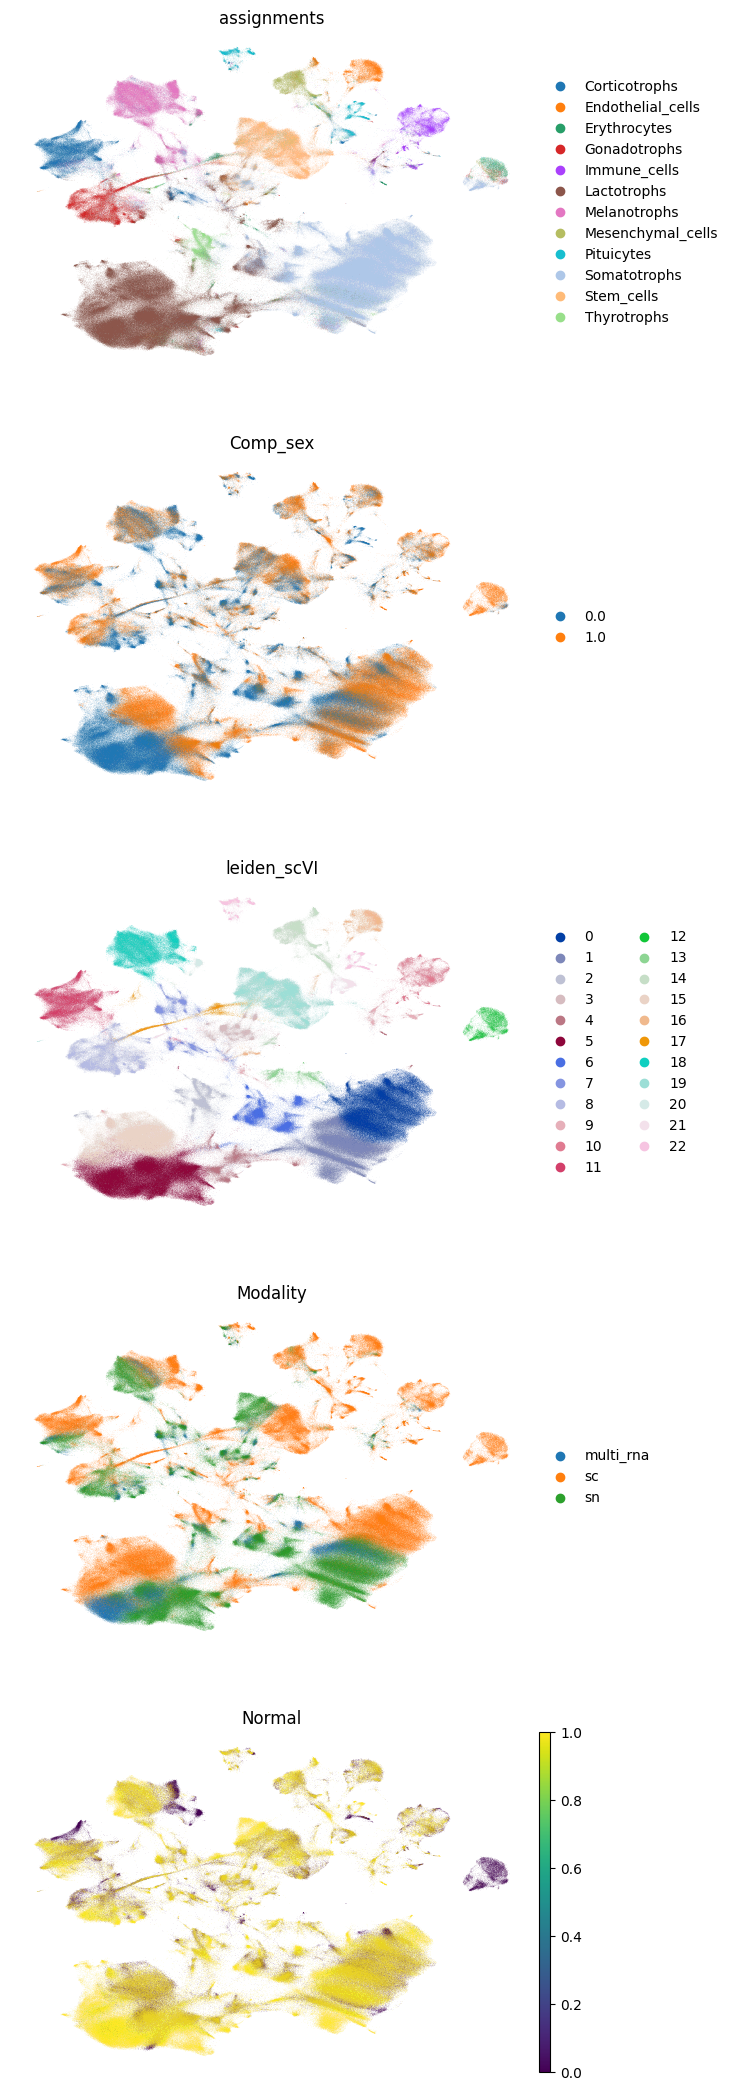

In [41]:
sc.pl.umap(
    adata_final,
    color=["assignments","Comp_sex","leiden_scVI","Modality","Normal"],
    frameon=False,
    ncols=1,
    layer="SCVI_normalised",
)

In [42]:
sc.pp.neighbors(adata_final, use_rep="X_scVI", n_neighbors=100)

In [43]:
#Change Mesenchymal_cells to Pericytes
#adata_final.obs['assignments'] = (
#    adata_final.obs['assignments']
#    .replace('Mesenchymal_cells', 'Pericytes')
#)


In [44]:
import numpy as np
import pandas as pd
import scanpy as sc
from tqdm import tqdm

def optimize_cell_type_assignment(object, rep="X_scVI", n_neighbors=100, threshold=0.6666):
    """
    Optimized function for cell type assignment using neighbor voting.
    If the majority vote is less than the threshold (default 50%), leave the cell type unchanged.
   
    Args:
        object: AnnData object
        rep: String representation to use for neighbor computation
        n_neighbors: Number of neighbors to consider
        threshold: Minimum proportion of neighbors required for a vote to update the cell type
    """

    if 'new_cell_type' not in object.obs.columns:
        cell_types = object.obs['assignments'].values
    else:
        cell_types = object.obs['new_cell_type'].values


    # Compute neighbors if not already present
    if 'new_cell_type' not in object.obs.columns:
        object.obs['new_cell_type'] = object.obs['assignments'].copy()
   
    # Get connectivity matrix in CSR format for efficient row slicing
    connectivity_matrix = object.obsp['connectivities'].tocsr()


    unknown_mask = cell_types != "unknown"
    unknown_indices = np.where(unknown_mask)[0]
   
    # Process unknown cells in batches for memory efficiency
    batch_size = 1000
    for batch_start in tqdm(range(0, len(unknown_indices), batch_size), desc="Processing batches"):
        batch_indices = unknown_indices[batch_start:batch_start + batch_size]
       
        # Get neighbor indices for current batch
        neighbor_indices = [
            connectivity_matrix[idx].indices[:n_neighbors]
            for idx in batch_indices
        ]
       
        # Get neighbor types for all cells in batch at once
        neighbor_types = [
            cell_types[indices][cell_types[indices] != "unknown"]
            for indices in neighbor_indices
        ]
       
        # Calculate majority vote for each cell
        majority_types = []
        for idx, types in zip(batch_indices, neighbor_types):
            if len(types) > 0:
                # Use np.unique to find the most common type
                unique, counts = np.unique(types, return_counts=True)
                majority_type = unique[np.argmax(counts)]
                majority_count = counts[np.argmax(counts)]
                majority_proportion = majority_count / len(types)

                # Only update the cell type if the majority vote is at least the threshold (e.g., 60%)
                if majority_proportion >= threshold:
                    majority_types.append(majority_type)
                else:
                    # If the majority proportion is less than the threshold, keep the current cell's type
                    majority_types.append(cell_types[idx])
            else:
                # If no neighbors have a type, keep the current cell's type
                majority_types.append(cell_types[idx])
        
        # Update the cell type for the current batch of cells
        object.obs['new_cell_type'].iloc[batch_indices] = majority_types
    
    # Calculate the number of differences between assignments and new_cell_type
    differences = (object.obs['assignments'] != object.obs['new_cell_type']).sum()
    
    # Print the number of differences
    print(f"Number of differences between assignments and new_cell_type: {differences}")
    

    return object

adata_final.obs['new_cell_type'] = adata_final.obs['assignments'] 
unknown_cells = optimize_cell_type_assignment(adata_final)
unknown_cells = optimize_cell_type_assignment(adata_final)
unknown_cells = optimize_cell_type_assignment(adata_final)

Processing batches:   0%|          | 0/954 [00:00<?, ?it/s]

/tmp/ipykernel_926/2321797853.py:73: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  object.obs['new_cell_type'].iloc[batch_indices] = majority_types
Processing batches: 100%|██████████| 954/954 [01:01<00:00, 15.45it/s]


Number of differences between assignments and new_cell_type: 37792


Processing batches: 100%|██████████| 954/954 [01:01<00:00, 15.47it/s]


Number of differences between assignments and new_cell_type: 45775


Processing batches: 100%|██████████| 954/954 [01:01<00:00, 15.63it/s]

Number of differences between assignments and new_cell_type: 48902


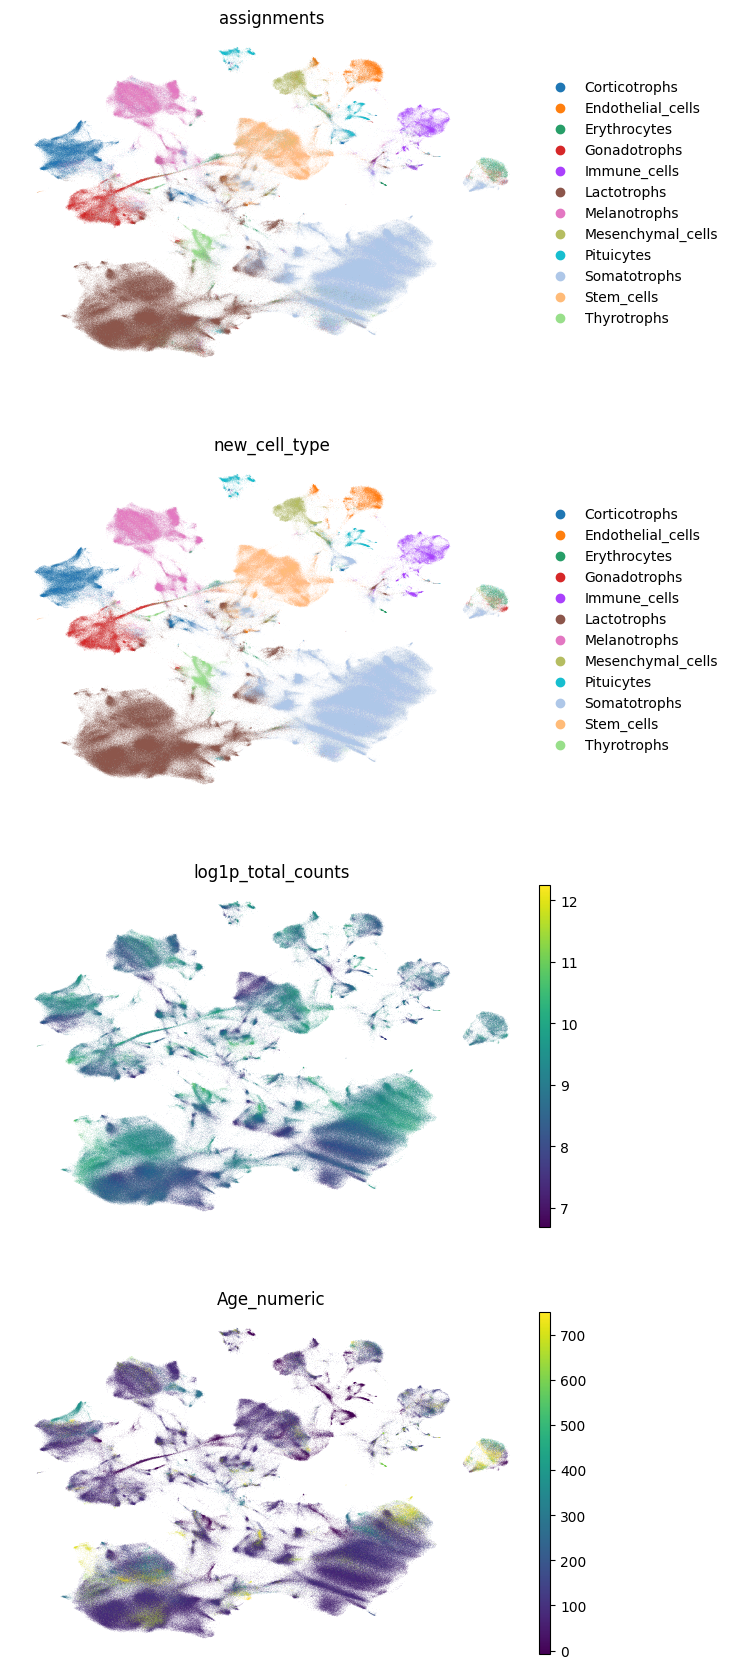

In [45]:
sc.pl.umap(
    adata_final,
    color=["assignments","new_cell_type","log1p_total_counts","Age_numeric"],
    frameon=False,
    ncols=1,
    layer="SCVI_normalised",
)


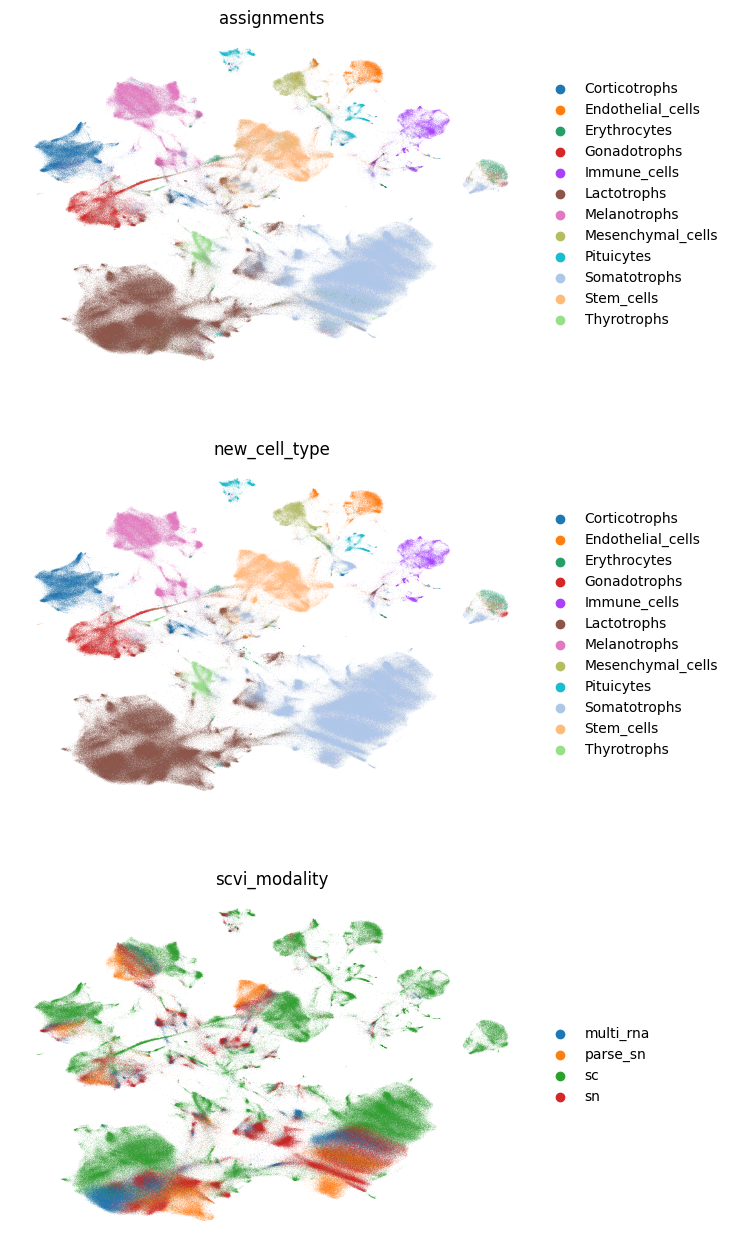

In [46]:
sc.pl.umap(
    adata_final,
    color=["assignments","new_cell_type","scvi_modality"],
    frameon=False,
    ncols=1,
    layer="SCVI_normalised",
)

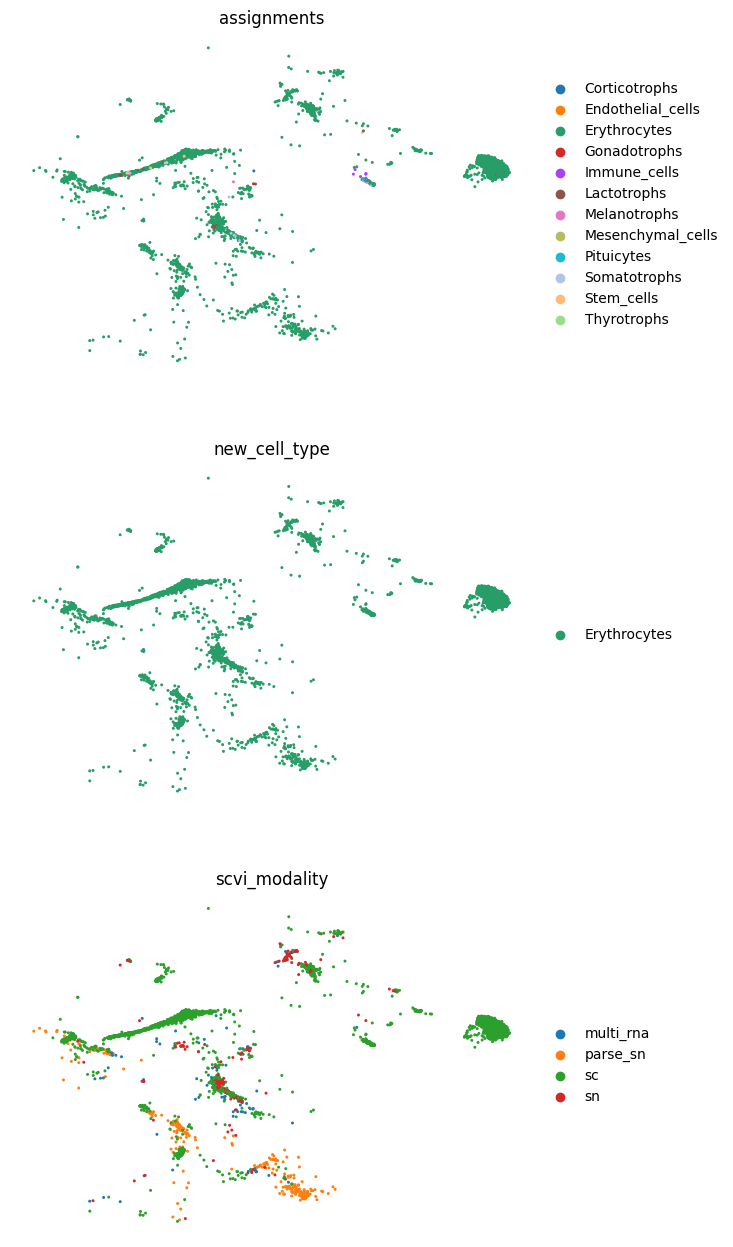

In [47]:
sc.pl.umap(
    adata_final[adata_final.obs["new_cell_type"]=="Erythrocytes"],
    color=["assignments","new_cell_type","scvi_modality"],
    frameon=False,
    ncols=1,
    layer="SCVI_normalised",
)

# Continuing with scANVI - improves embedding for visualisations

In [48]:
import gc
gc.collect()

39032

In [49]:
scanvi_model = scvi.model.SCANVI.from_scvi_model(
    vae,
    adata=adata_final,
    labels_key="new_cell_type",
    unlabeled_category="Unknown",
)

scanvi_model.to_device("cuda:0")

In [50]:
scanvi_model.train(max_epochs=50)

INFO     Training for 50 epochs.                                                                                   


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/darwin/miniconda3/envs/bencenv_wsl/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=55` in the `DataLoader` to improve performance.


Epoch 50/50: 100%|██████████| 50/50 [3:01:28<00:00, 216.33s/it, v_num=1, train_loss_step=1.3e+3, train_loss_epoch=1.29e+3]   

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 50/50: 100%|██████████| 50/50 [3:01:28<00:00, 217.77s/it, v_num=1, train_loss_step=1.3e+3, train_loss_epoch=1.29e+3]


In [ ]:
scanvi_dir = "/mnt/g/cpa/scanvi_2026_02_03/"
scanvi_model.save(dir_path=scanvi_dir)
scanvi_model = scvi.model.SCANVI.load(scanvi_dir , adata_final)

INFO     File /mnt/g/cpa/scanvi_2026_02_03/model.pt already downloaded                                             


In [52]:
SCANVI_LATENT_KEY = "X_scANVI"
adata_final.obsm[SCANVI_LATENT_KEY] = scanvi_model.get_latent_representation(adata_final)

In [53]:
import gc
gc.collect()

2897

In [54]:
sc.pp.neighbors(adata_final, use_rep=SCANVI_LATENT_KEY)
sc.tl.leiden(adata_final, resolution=1, key_added="leiden_scanVI", random_state=42,flavor="igraph")
sc.tl.umap(adata_final)

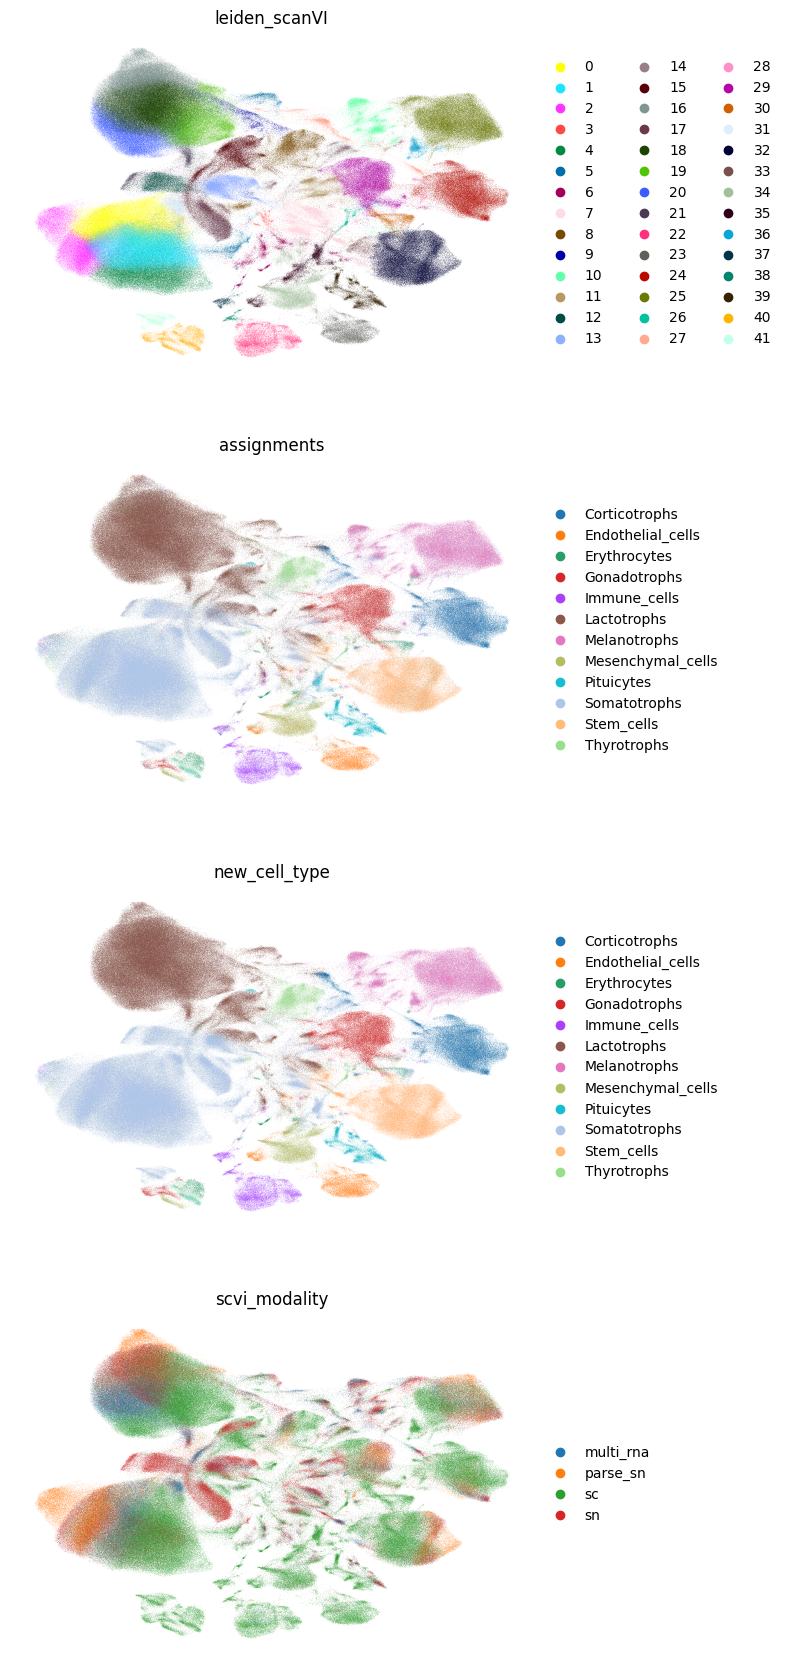

In [55]:
sc.pl.umap(
    adata_final,
    color=["leiden_scanVI","assignments","new_cell_type","scvi_modality",],
    frameon=False,
    ncols=1,
    layer="SCVI_normalised",
)

In [57]:
adata_final.obs["new_cell_type"]

0         Somatotrophs
1         Somatotrophs
2          Lactotrophs
3          Lactotrophs
4          Lactotrophs
              ...     
953241    Somatotrophs
953242    Somatotrophs
953243    Somatotrophs
953244    Somatotrophs
953245    Somatotrophs
Name: new_cell_type, Length: 953246, dtype: category
Categories (12, object): ['Corticotrophs', 'Endothelial_cells', 'Erythrocytes', 'Gonadotrophs', ..., 'Pituicytes', 'Somatotrophs', 'Stem_cells', 'Thyrotrophs']

In [59]:
adata_final.var

,Unnamed: 0,n_cells,mt,ribo,malat,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts,feature_types
0,0610039K10Rik,1995,False,False,False,1995,0.002237,0.002234,99.790715,2132,7.665285,mrna
1,0710001A04Rik,1503,False,False,False,1503,0.001659,0.001657,99.842328,1581,7.366445,mrna
2,1100001I12Rik,1227,False,False,False,1227,0.001346,0.001345,99.871282,1283,7.157735,mrna
3,1110015O18Rik,200,False,False,False,200,0.000224,0.000224,99.979019,214,5.370638,mrna
4,1110019D14Rik,139186,False,False,False,139186,0.205236,0.186675,85.398732,195640,12.184036,mrna
...,...,...,...,...,...,...,...,...,...,...,...,...
4995,Zscan10,840,False,False,False,840,0.000927,0.000927,99.911880,884,6.785588,mrna
4996,Zswim2,346,False,False,False,346,0.000376,0.000375,99.963703,358,5.883322,mrna
4997,Zswim3,54821,False,False,False,54821,0.066792,0.064656,94.249019,63669,11.061469,mrna
4998,Zswim5,124748,False,False,False,124748,0.197036,0.179849,86.913347,187824,12.143266,mrna


In [64]:
adata_final.var.index = adata_final.var["Unnamed: 0"].astype(str)

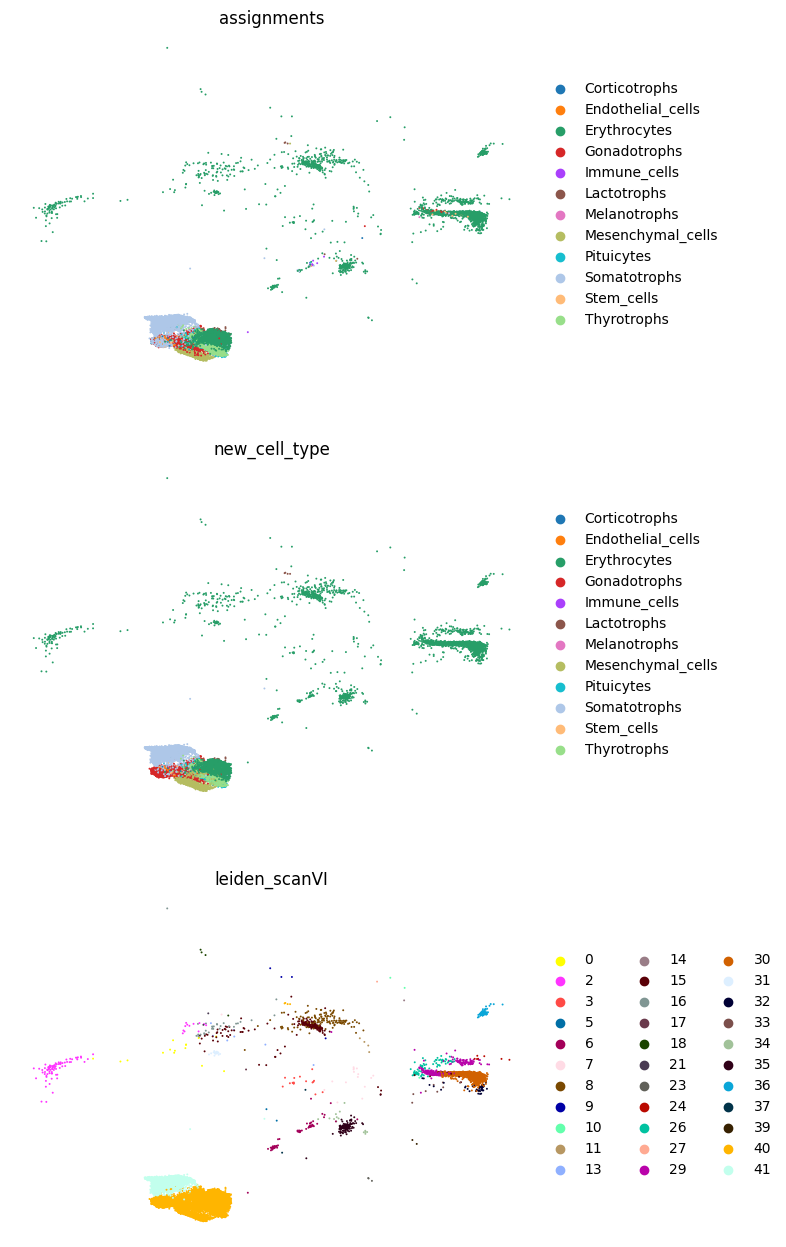

In [65]:
import numpy as np

# 1. Get Hbb-bt expression from the desired layer
# We use toarray().flatten() to ensure it's a 1D array for comparison
hbb_expr = adata_final.layers["counts"][:, adata_final.var_names == "Hbb-bt"].toarray().flatten()

# 2. Condition A: Is Erythrocyte AND has < 1 Hbb-bt
cond_eryth = (adata_final.obs["new_cell_type"] == "Erythrocytes") & (hbb_expr < 1)

# 3. Condition B: Is in specific clusters
cond_clusters = adata_final.obs["leiden_scanVI"].isin(["40", "41"])

# 4. Combine with OR (|)
mask = cond_eryth | cond_clusters

# Plotting
sc.pl.umap(
    adata_final[mask],
    color=["assignments", "new_cell_type", "leiden_scanVI"],
    frameon=False,
    ncols=1,
    layer="SCVI_normalised",
)

In [68]:
np.sum(cond_clusters)

np.int64(12717)

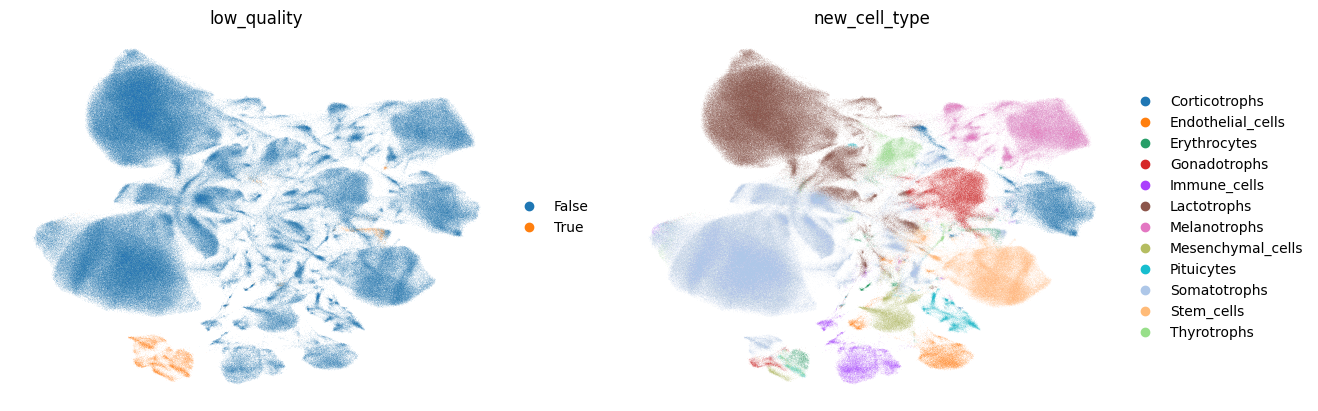

In [69]:
import numpy as np

# 1. Extract Hbb-bt expression safely
hbb_expr = adata_final.layers["counts"][:, adata_final.var_names == "Hbb-bt"].toarray().flatten()

# 2. Define the logic
cond_eryth = (adata_final.obs["new_cell_type"] == "Erythrocytes") & (hbb_expr < 1)
cond_clusters = adata_final.obs["leiden_scanVI"].isin(["40", "41"])

# 3. Create the mask and add to .obs
adata_final.obs["low_quality"] = cond_eryth | cond_clusters

# 4. Plot to verify the distribution of these "low_quality" cells
sc.pl.umap(
    adata_final,
    color=["low_quality", "new_cell_type"],
    frameon=False,
    ncols=2,
)

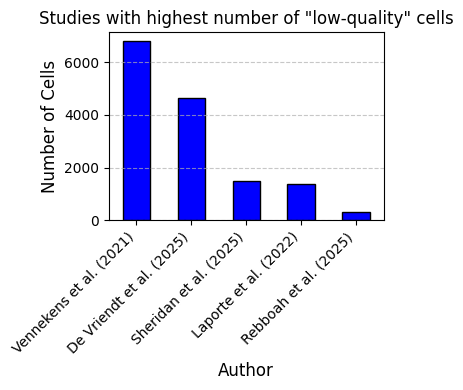

In [70]:
import matplotlib.pyplot as plt

# 1. Calculate the counts for cells flagged as low_quality
low_quality_counts = adata_final[adata_final.obs["low_quality"]].obs["Author"].value_counts()

# 2. Select the top 5
top_5_authors = low_quality_counts.nlargest(5)

# 3. Create the bar plot
plt.figure(figsize=(4, 4))
top_5_authors.plot(kind='bar', color='blue', edgecolor='black')

plt.title('Studies with highest number of "low-quality" cells', fontsize=12)
plt.xlabel('Author', fontsize=12)
plt.ylabel('Number of Cells', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# --- SAVE LOGIC START ---
out_base = "/mnt/g/cpa/barplot_low_quality"

# Save as PNG with 500 DPI
plt.savefig(f"{out_base}.png", dpi=500, bbox_inches='tight')

# Save as SVG (Scalable Vector Graphics)
plt.savefig(f"{out_base}.svg", bbox_inches='tight')
# --- SAVE LOGIC END ---

plt.show()


In [71]:

#save values of .obs, specifically  SRA_ID, "assignments","GEO,"leiden_scVI"
output_path = '/mnt/g/cpa/assignments_leiden_obs_2026_01_30.csv'
#adata_final.obs[["0","GEO","SRA_ID","assignments","leiden_scVI","new_cell_type"]]
adata_final.obs.to_csv(output_path, index=False)
adata_final.obs = pd.read_csv('/mnt/g/cpa/assignments_leiden_obs_2026_01_30.csv')
adata_final.obs["Comp_sex"] = (
    adata_final.obs["Comp_sex"]
    .astype(str)  # convert floats to string
    .astype("category")  # then to categorical
)


/tmp/ipykernel_926/1387146700.py:5: DtypeWarning: Columns (0,1,18,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,46,47,48,49,50,53,54,57,63,64,68,80,81,92,94,95) have mixed types. Specify dtype option on import or set low_memory=False.
  adata_final.obs = pd.read_csv('/mnt/g/cpa/assignments_leiden_obs_2026_01_30.csv')


In [72]:
import pandas as pd

# Convert to DataFrame
umap_df = pd.DataFrame(adata_final.obsm["X_umap"], columns=["UMAP1", "UMAP2"])

# Save as CSV
umap_df.to_csv("/mnt/g/cpa/umap_coordinates_2026_01_30.csv", index=False)


In [73]:
adata_final.obs = adata_final.obs.astype(str)
adata_final.var = adata_final.var.astype(str)

In [74]:
# Add UMAP coordinates to .obs
adata_final.obs["UMAP1"] = adata_final.obsm["X_umap"][:, 0]
adata_final.obs["UMAP2"] = adata_final.obsm["X_umap"][:, 1]

# Remove .uns, .obsm, and .obsp
adata_final.uns = {}
adata_final.obsm = {}
adata_final.obsp = {}


In [75]:
adata_final

AnnData object with n_obs × n_vars = 953246 × 5000
    obs: 'Unnamed: 0', '0', 'n_genes', 'n_counts', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_malat', 'log1p_total_counts_malat', 'pct_counts_malat', 'doublet_score', 'predicted_doublet', 'size_factor', 'assignments', 'SRA_ID', 'GEO_x', 'assay', 'orig_index', 'lab_sample_id', 'sample', 'plate', 'subpool', 'SampleType', 'Tissue', 'Sex_x', 'Age_x', 'Genotype', 'subpool_type', 'Protocol', 'Chemistry', 'bc', 'bc1_sequence', 'bc2_sequence', 'bc3_sequence', 'bc1_well', 'bc2_well', 'bc3_well', 'Row', 'Column', 'well_type', 'Mouse_Tissue_ID', 'Multiplexed_sample1', 'Multiplexed_sample2', 'DOB', 'Age_days', 'Body_weight_g', 'Estrus_cycle', 'Dissection_date', 'batch', 'GEO_y', 'Name', 'Conditions', 'Normal', 'Background', 'Sorted', 'Author', 'DOI', 'Age_y', 'Sex_n

In [76]:
adata_final.write("/mnt/g/cpa/scanvi_all_cells_2026_01_30.h5ad",compression="gzip")

In [77]:
#load back 
import scanpy as sc
import pandas as pd
adata_final = sc.read("/mnt/g/cpa/scanvi_all_cells_2026_01_30.h5ad")
adata_final

/home/darwin/miniconda3/envs/bencenv_wsl/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


AnnData object with n_obs × n_vars = 953246 × 5000
    obs: 'Unnamed: 0', '0', 'n_genes', 'n_counts', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_malat', 'log1p_total_counts_malat', 'pct_counts_malat', 'doublet_score', 'predicted_doublet', 'size_factor', 'assignments', 'SRA_ID', 'GEO_x', 'assay', 'orig_index', 'lab_sample_id', 'sample', 'plate', 'subpool', 'SampleType', 'Tissue', 'Sex_x', 'Age_x', 'Genotype', 'subpool_type', 'Protocol', 'Chemistry', 'bc', 'bc1_sequence', 'bc2_sequence', 'bc3_sequence', 'bc1_well', 'bc2_well', 'bc3_well', 'Row', 'Column', 'well_type', 'Mouse_Tissue_ID', 'Multiplexed_sample1', 'Multiplexed_sample2', 'DOB', 'Age_days', 'Body_weight_g', 'Estrus_cycle', 'Dissection_date', 'batch', 'GEO_y', 'Name', 'Conditions', 'Normal', 'Background', 'Sorted', 'Author', 'DOI', 'Age_y', 'Sex_n

In [78]:
import pandas as pd

# Load saved UMAP coordinates
umap_df = pd.read_csv("/mnt/g/cpa/umap_coordinates_2026_01_30.csv")

# Assign back to AnnData
adata_final.obsm["X_umap"] = umap_df[["UMAP1", "UMAP2"]].values


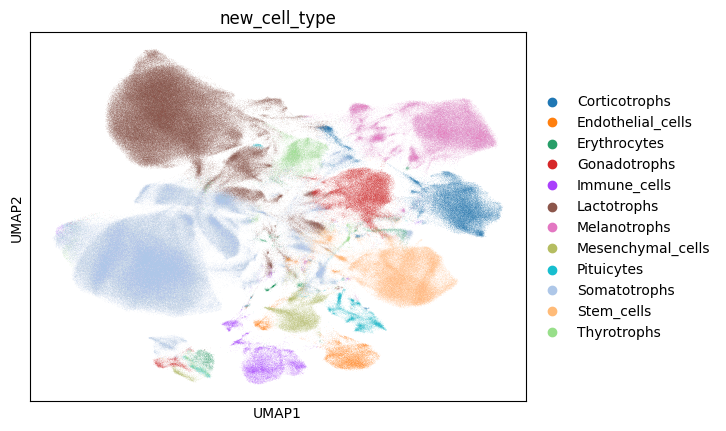

In [79]:
fig = sc.pl.umap(
    adata_final,
    color=["new_cell_type"],wspace=0.45,
    sort_order=False,
    return_fig=True,
    show=False
)

out_base = "/mnt/g/cpa/umap_rna_atlas_annotated_celltype"

# PNG (500 DPI)
fig.savefig(
    f"{out_base}.png",
    dpi=500,
    bbox_inches="tight"
)

# SVG (vector)
fig.savefig(
    f"{out_base}.svg",
    bbox_inches="tight"
)

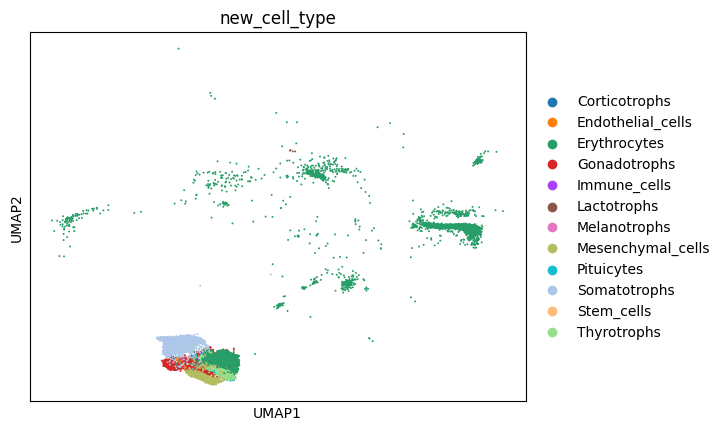

In [80]:
# Convert the column to actual booleans
adata_final.obs["low_quality"] = adata_final.obs["low_quality"].astype(str) == "True"

fig = sc.pl.umap(
    adata_final[adata_final.obs["low_quality"]],
    color=["new_cell_type"],wspace=0.45,
    sort_order=False,
    return_fig=True,
    show=False
)

out_base = "/mnt/g/cpa/umap_rna_atlas_annotated_celltype_junk"

# PNG (500 DPI)
fig.savefig(
    f"{out_base}.png",
    dpi=500,
    bbox_inches="tight"
)

# SVG (vector)
fig.savefig(
    f"{out_base}.svg",
    bbox_inches="tight"
)

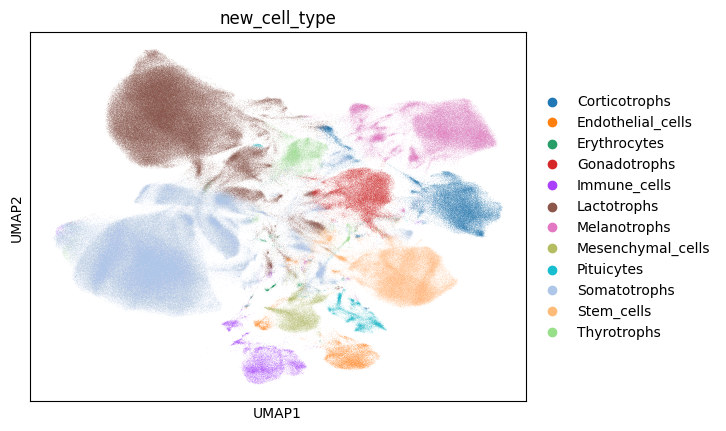

In [81]:
fig = sc.pl.umap(
    adata_final[~adata_final.obs["low_quality"]],
    color=["new_cell_type"],wspace=0.45,
    sort_order=False,
    return_fig=True,
    show=False
)
out_base = "/mnt/g/cpa/umap_rna_atlas_annotated_celltype_final"

# PNG (500 DPI)
fig.savefig(
    f"{out_base}.png",
    dpi=500,
    bbox_inches="tight"
)

# SVG (vector)
fig.savefig(
    f"{out_base}.svg",
    bbox_inches="tight"
)

/home/darwin/miniconda3/envs/bencenv_wsl/lib/python3.11/site-packages/scanpy/plotting/_utils.py:491: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


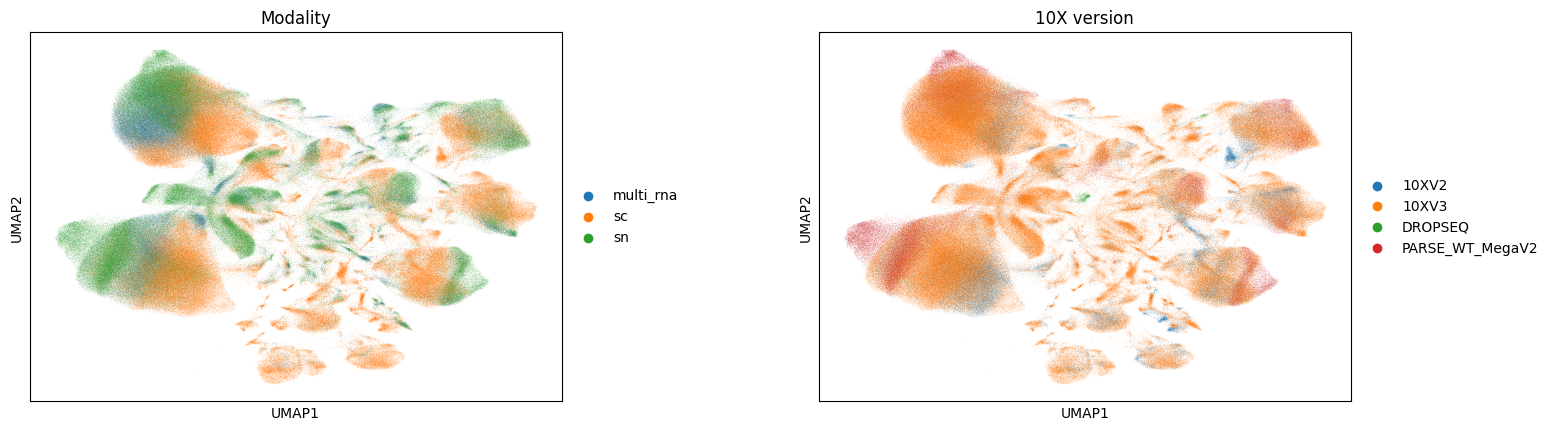

In [82]:
fig = sc.pl.umap(
    adata_final[~adata_final.obs["low_quality"]],
    color=["Modality","10X version"],wspace=0.35,
    sort_order=False,
    return_fig=True,
    show=False
)

out_base = "/mnt/g/cpa/umap_rna_atlas_annotated_celltype_metadata_final"

# PNG (500 DPI)
fig.savefig(
    f"{out_base}.png",
    dpi=900,
    bbox_inches="tight"
)

# SVG (vector)
fig.savefig(
    f"{out_base}.svg",
    bbox_inches="tight"
)

/home/darwin/miniconda3/envs/bencenv_wsl/lib/python3.11/site-packages/scanpy/plotting/_utils.py:491: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


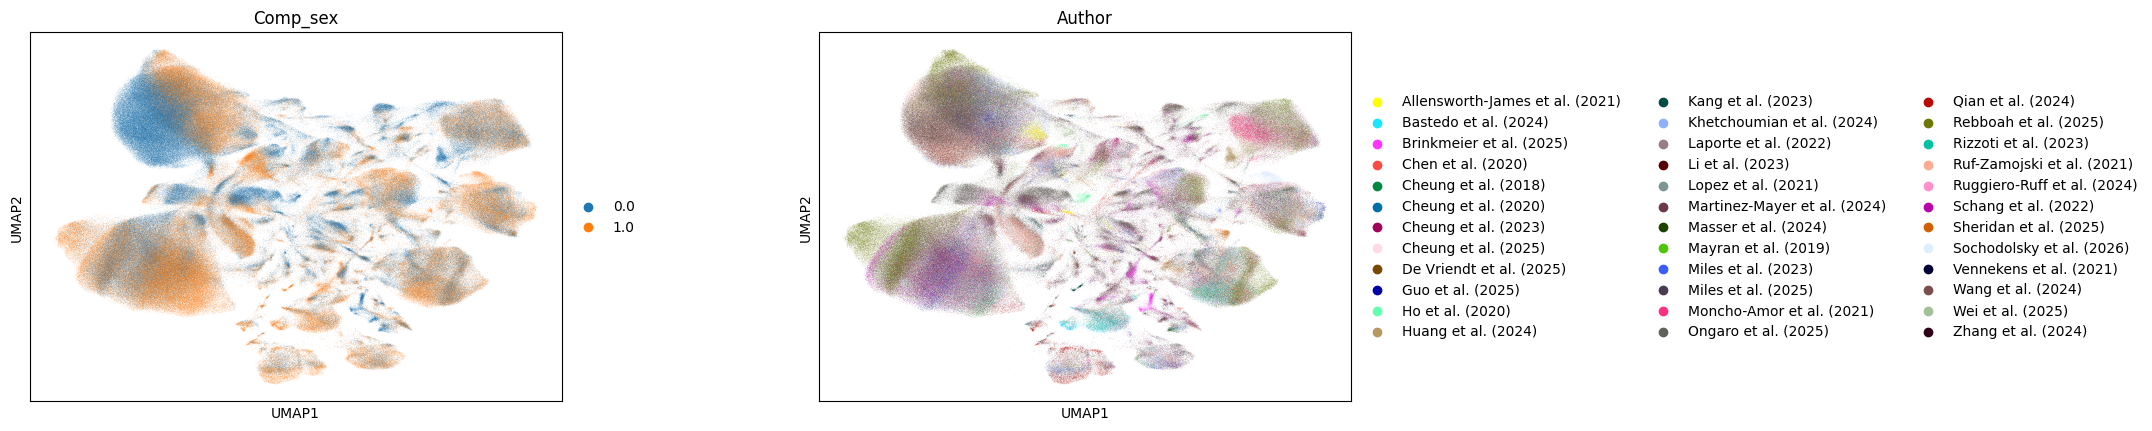

In [83]:
fig = sc.pl.umap(
    adata_final[~adata_final.obs["low_quality"]],
    color=["Comp_sex","Author"],wspace=0.35,
    sort_order=False,
    return_fig=True,
    show=False
)

out_base = "/mnt/g/cpa/umap_rna_atlas_annotated_celltype_metadata2_final"

# PNG (500 DPI)
fig.savefig(
    f"{out_base}.png",
    dpi=900,
    bbox_inches="tight"
)

# SVG (vector)
fig.savefig(
    f"{out_base}.svg",
    bbox_inches="tight"
)

# scIB integration scores

In [88]:
pip install scib-metrics

Note: you may need to restart the kernel to use updated packages.


In [ ]:
adata_final = sc.read("/mnt/g/cpa/scvi_all_cells_2026_01_30.h5ad")

df_var = pd.read_excel("/mnt/g/cpa/df_var_2026_01_30.xlsx")
adata_final.var = df_var

In [90]:
adata_final.obs = pd.read_csv('/mnt/g/cpa/assignments_leiden_obs_2026_01_30.csv')

/tmp/ipykernel_926/1709043270.py:1: DtypeWarning: Columns (0,1,18,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,46,47,48,49,50,53,54,57,63,64,68,80,81,92,94,95) have mixed types. Specify dtype option on import or set low_memory=False.
  adata_final.obs = pd.read_csv('/mnt/g/cpa/assignments_leiden_obs_2026_01_30.csv')


In [93]:
adata_final.obs["Comp_sex"] = adata_final.obs["Comp_sex"].astype(str)

In [94]:
vae = scvi.model.SCVI.load("/mnt/g/cpa/vae_2026_02_03", adata_final)
scanvi_model = scvi.model.SCANVI.load("/mnt/g/cpa/scanvi_2026_02_03/", adata_final)

INFO     File /mnt/g/cpa/vae_2026_02_03/model.pt already downloaded                                                


/home/darwin/miniconda3/envs/bencenv_wsl/lib/python3.11/site-packages/scvi/model/base/_base_model.py:830: UserWarning: `var_names` for the loaded `model` does not match those used to train the model. For valid results, the former should match the latter.
  _validate_var_names(adata, var_names)


INFO     File /mnt/g/cpa/scanvi_2026_02_03/model.pt already downloaded                                             


In [95]:
#get scvi embedding
#get scanvi embedding
adata_final.obsm["X_scVI"] = vae.get_latent_representation()
adata_final.obsm["X_scANVI"] = scanvi_model.get_latent_representation(adata_final)

In [103]:
import scib_metrics
from scib_metrics.benchmark import Benchmarker
import numpy as np
adata_final.obs_names = adata_final.obs_names.astype(str)
if adata_final.n_obs > 50000:
    indices = np.random.choice(adata_final.obs_names, 500000, replace=False)
    bm_adata = adata_final[indices].copy()
else:
    bm_adata = adata_final


/home/darwin/miniconda3/envs/bencenv_wsl/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [104]:
bm_adata

AnnData object with n_obs × n_vars = 500000 × 5000
    obs: 'Unnamed: 0', '0', 'n_genes', 'n_counts', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_malat', 'log1p_total_counts_malat', 'pct_counts_malat', 'doublet_score', 'predicted_doublet', 'size_factor', 'assignments', 'SRA_ID', 'GEO_x', 'assay', 'orig_index', 'lab_sample_id', 'sample', 'plate', 'subpool', 'SampleType', 'Tissue', 'Sex_x', 'Age_x', 'Genotype', 'subpool_type', 'Protocol', 'Chemistry', 'bc', 'bc1_sequence', 'bc2_sequence', 'bc3_sequence', 'bc1_well', 'bc2_well', 'bc3_well', 'Row', 'Column', 'well_type', 'Mouse_Tissue_ID', 'Multiplexed_sample1', 'Multiplexed_sample2', 'DOB', 'Age_days', 'Body_weight_g', 'Estrus_cycle', 'Dissection_date', 'batch', 'GEO_y', 'Name', 'Conditions', 'Normal', 'Background', 'Sorted', 'Author', 'DOI', 'Age_y', 'Sex_n

In [ ]:
bm = Benchmarker(
    adata_final,
    batch_key="SRA_ID",           # Replace with your actual batch column name
    label_key="new_cell_type",    # Using the labels you gave scANVI
    embedding_obsm_keys=['X_pca','X_scVI','X_scANVI'],
)

# 4. Run it
bm.benchmark()




/home/darwin/miniconda3/envs/bencenv_wsl/lib/python3.11/site-packages/scanpy/preprocessing/_pca/__init__.py:439: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  warn(msg, FutureWarning)
Embeddings:   0%|          | 0/3 [00:00<?, ?it/s]

In [ ]:
# 5. Extract and show results
results = bm.get_results(min_max_scale=True)

/home/darwin/miniconda3/envs/bencenv_wsl/lib/python3.11/site-packages/sklearn/utils/_array_api.py:695: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmin(X, axis=axis))
/home/darwin/miniconda3/envs/bencenv_wsl/lib/python3.11/site-packages/sklearn/utils/_array_api.py:712: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmax(X, axis=axis))
/home/darwin/miniconda3/envs/bencenv_wsl/lib/python3.11/site-packages/scib_metrics/benchmark/_core.py:291: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Aggregate score' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[_METRIC_TYPE, per_class_score.columns] = _AGGREGATE_SCORE
/home/darwin/miniconda3/envs/bencenv_wsl/lib/python3.11/site-packages/scib_metrics/benchmark/_core.py:291: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a fu

In [ ]:
from rich import print

df = bm.get_results(min_max_scale=False)
print(df)

Isolated labels        KMeans NMI        KMeans ARI  \
Embedding                                                           
X_pca                0.304003           0.19238         -0.068891   
X_scVI               0.482983          0.674531          0.484188   
X_scANVI             0.532588          0.742737          0.577854   
Metric Type  Bio conservation  Bio conservation  Bio conservation   

             Silhouette label             cLISI  Silhouette batch  \
Embedding                                                           
X_pca                0.287463               1.0          0.618879   
X_scVI               0.567712               1.0          0.854644   
X_scANVI             0.675689               1.0          0.789112   
Metric Type  Bio conservation  Bio conservation  Batch correction   

                        iLISI              KBET Graph connectivity  \
Embedding                                                            
X_pca                0.011998               NaN           0.826774   
X_scVI               0.015899               NaN            0.86205   
X_scANVI              0.01969               NaN           0.874532   
Metric Type  Batch correction  Batch correction   Batch correction   

               PCR comparison Batch correction Bio conservation  \
Embedding                                                         
X_pca                     0.0         0.364413         0.342991   
X_scVI               0.344449         0.519261         0.641883   
X_scANVI             0.327776         0.502778         0.705774   
Metric Type  Batch correction  Aggregate score  Aggregate score   

                       Total  
Embedding                     
X_pca                0.35156  
X_scVI              0.592834  
X_scANVI            0.624575  
Metric Type  Aggregate score

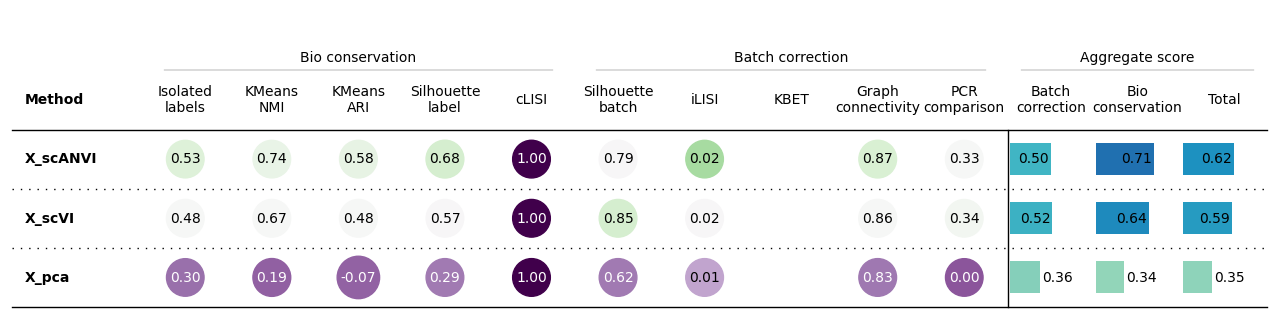

In [ ]:
bm.plot_results_table(min_max_scale=False)